## 1. Credit Card Dataset Overview
Inspecting anonymized features (V1-V28) and transaction classes

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Am setat tema pentru graficele Seaborn
sns.set_theme(style="whitegrid")

In [2]:
df_real = pd.read_csv('../data/creditcard.csv')

#Afișăm primele 5 rânduri și informații despre setul de date
display(df_real.head())
print("Dimensiunea setului de date:", df_real.shape)
print("\nInformații variabile:\n")
df_real.info()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dimensiunea setului de date: (284807, 31)

Informații variabile:

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float6

## 2. Class Imbalance Check
Visualizing the ratio between normal transactions and frauds


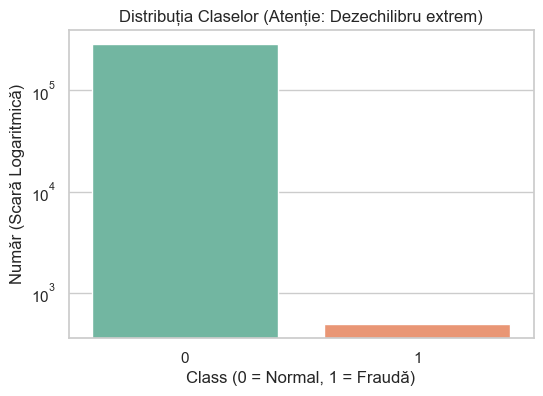

In [3]:
# Vizualizăm distribuția claselor (0 = Normal, 1 = Fraudă)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_real, x='Class', hue='Class', palette='Set2', legend=False)
plt.title('Distribuția Claselor (Atenție: Dezechilibru extrem)')
plt.yscale('log')       # Folosim logaritm pe  axa Y pentru a putea vedea linia mică a fraudelor
plt.xlabel('Class (0 = Normal, 1 = Fraudă)')
plt.ylabel('Număr (Scară Logaritmică)')
plt.show()

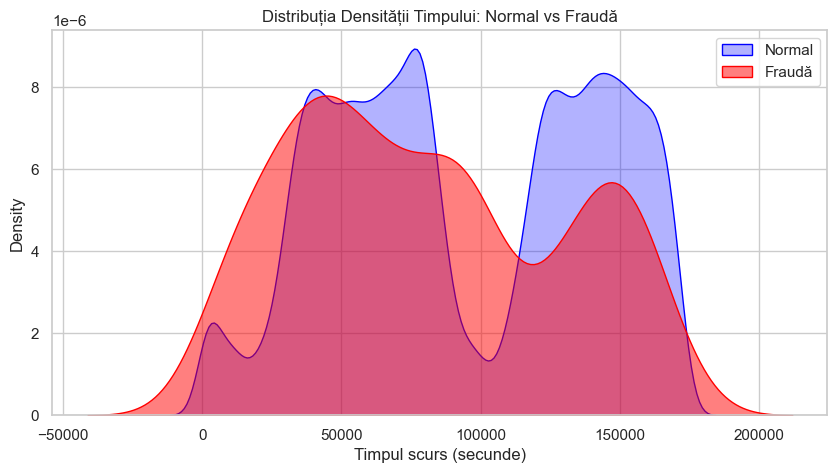

In [4]:
# Vedem dacă fraudele se petrec la anumite ore (în secunde)
plt.figure(figsize=(10, 5))
sns.kdeplot(df_real[df_real['Class'] == 0]['Time'], label='Normal', fill=True, color='blue', alpha=0.3)
sns.kdeplot(df_real[df_real['Class'] == 1]['Time'], label='Fraudă', fill=True, color='red', alpha=0.5)
plt.title('Distribuția Densității Timpului: Normal vs Fraudă')
plt.xlabel('Timpul scurs (secunde)')
plt.legend()
plt.show()

## 3. Feature Correlation Matrix
Understanding relationships between anonymized variables

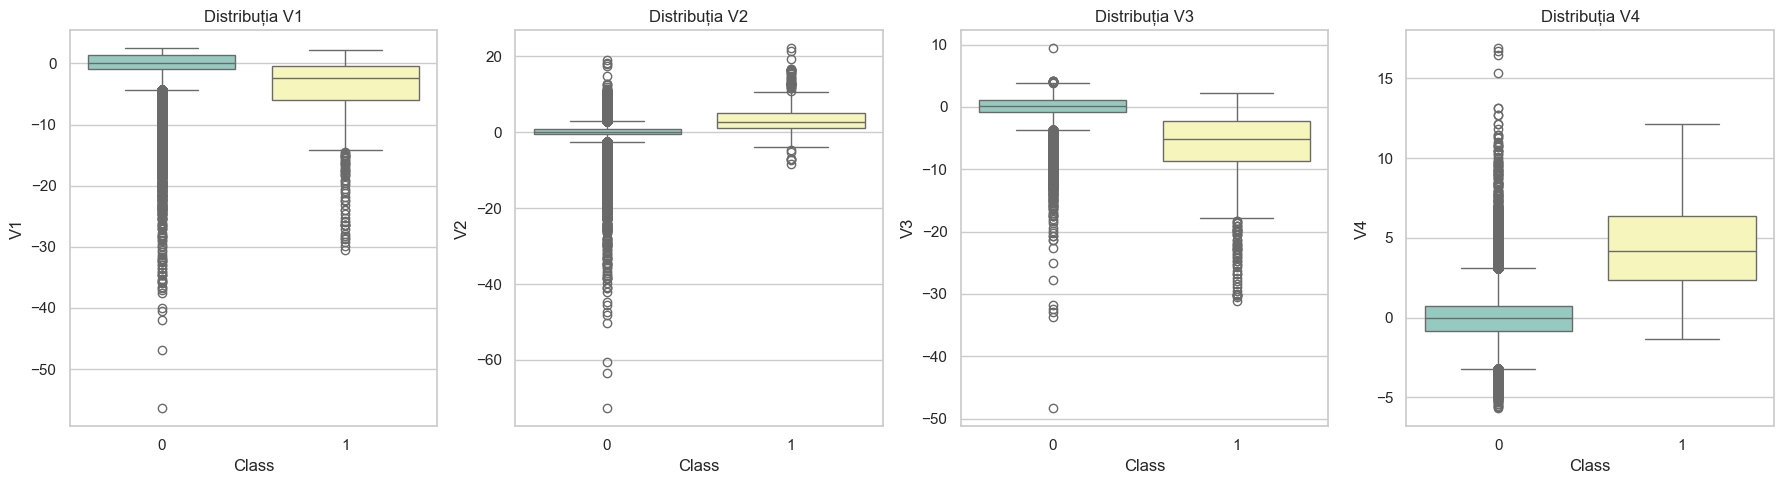

In [5]:
# Aici verificăm vizual dacă variabilele anonimizate pot separa fraudele
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(['V1', 'V2', 'V3', 'V4']):
    sns.boxplot(data=df_real, x='Class', y=col, hue='Class', ax=axes[i], palette='Set3', legend=False)
    axes[i].set_title(f'Distribuția {col}')

plt.tight_layout()
plt.show()

## 4. Feature Correlation Matrix
Analyzing dependencies between anonymized V-features

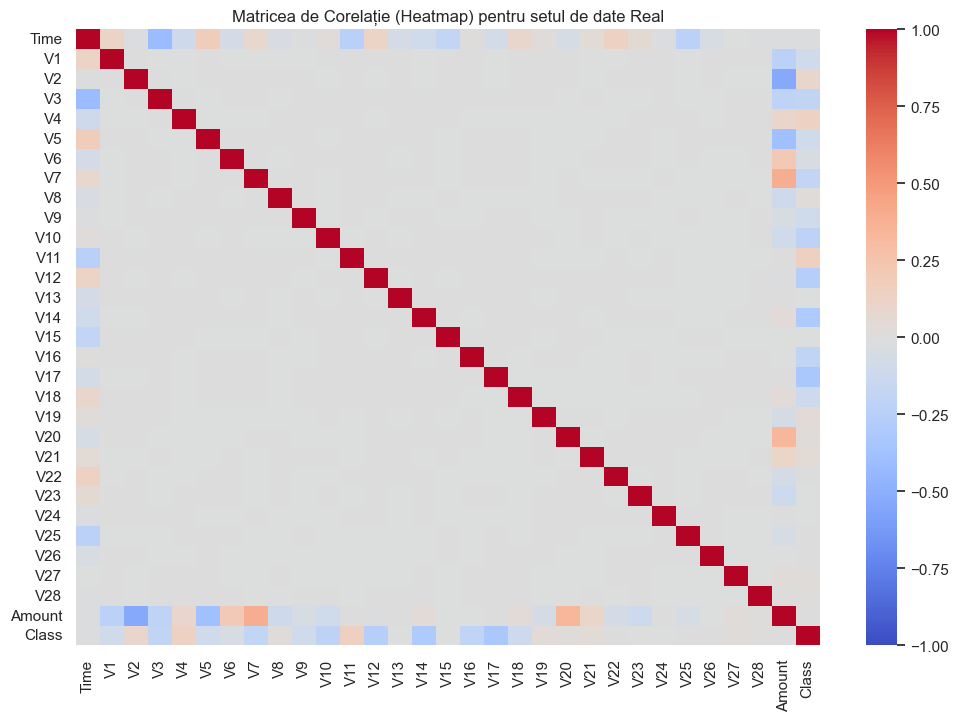

In [6]:
plt.figure(figsize=(12, 8))

# Calculăm corelația (Pearson) între toate coloanele
corr_matrix = df_real.corr()

# Desenăm Heatmap-ul
# Deoarece V1-V28 sunt create prin PCA, corelația între ele ar trebui să fie aproape 0.
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=-1, vmax=1)
plt.title('Matricea de Corelație (Heatmap) pentru setul de date Real')
plt.show()

## 5. PCA Visualization
Visualizing how fraud cases are clustered compared to normal transactions

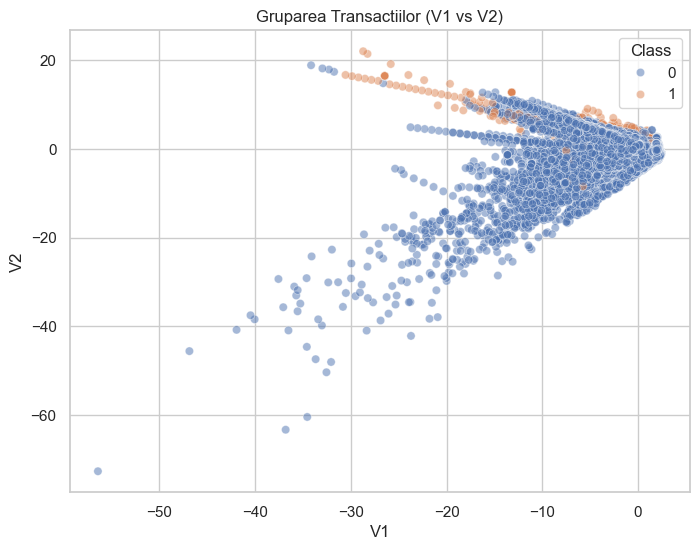

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_real, x='V1', y='V2', hue='Class', alpha=0.5)
plt.title('Gruparea Transactiilor (V1 vs V2)')
plt.show()

## 6. Advanced Correlation Analysis with the Target Variable (Class)
We identify which of the anonymized variables (V1–V28) have the greatest influence on fraud detection.


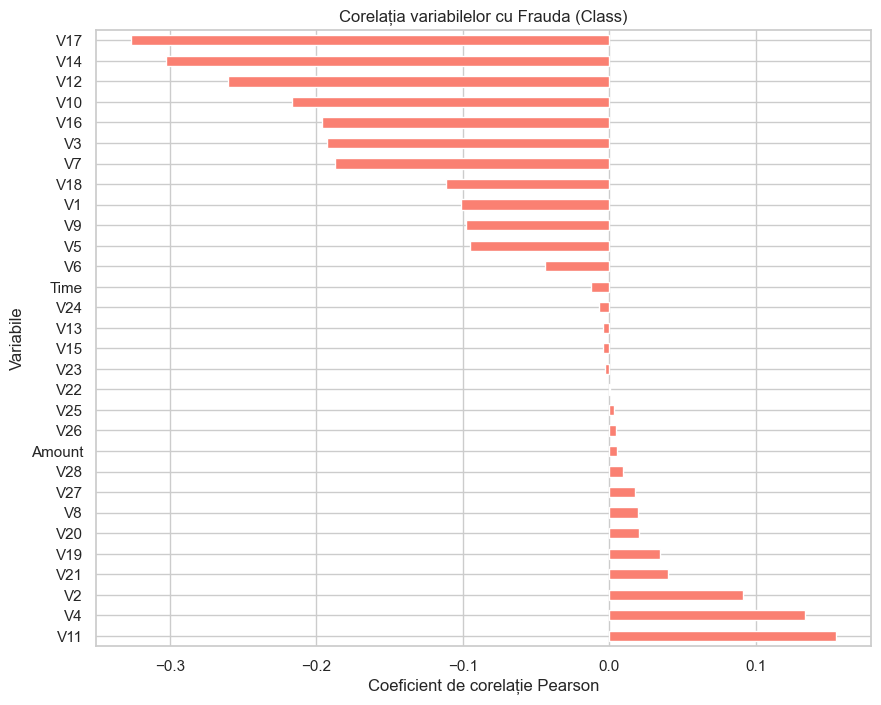

In [8]:
# Calculăm corelația tuturor variabilelor cu coloana 'Class'
correlations = df_real.corr()['Class'].sort_values(ascending=False)

# Vizualizăm variabilele cu cea mai mare corelație (excluzând Class însăși)
plt.figure(figsize=(10,8))
correlations.drop('Class').plot(kind='barh', color='salmon')
plt.title('Corelația variabilelor cu Frauda (Class)')
plt.xlabel('Coeficient de corelație Pearson')
plt.ylabel('Variabile')
plt.show()

## 7. Distribution of Critical Variables (KDE Plots)
We visualize the overlap of distributions for the variables with the strongest negative correlation (V17, V14, V12, V10), where the separation between classes is most evident.

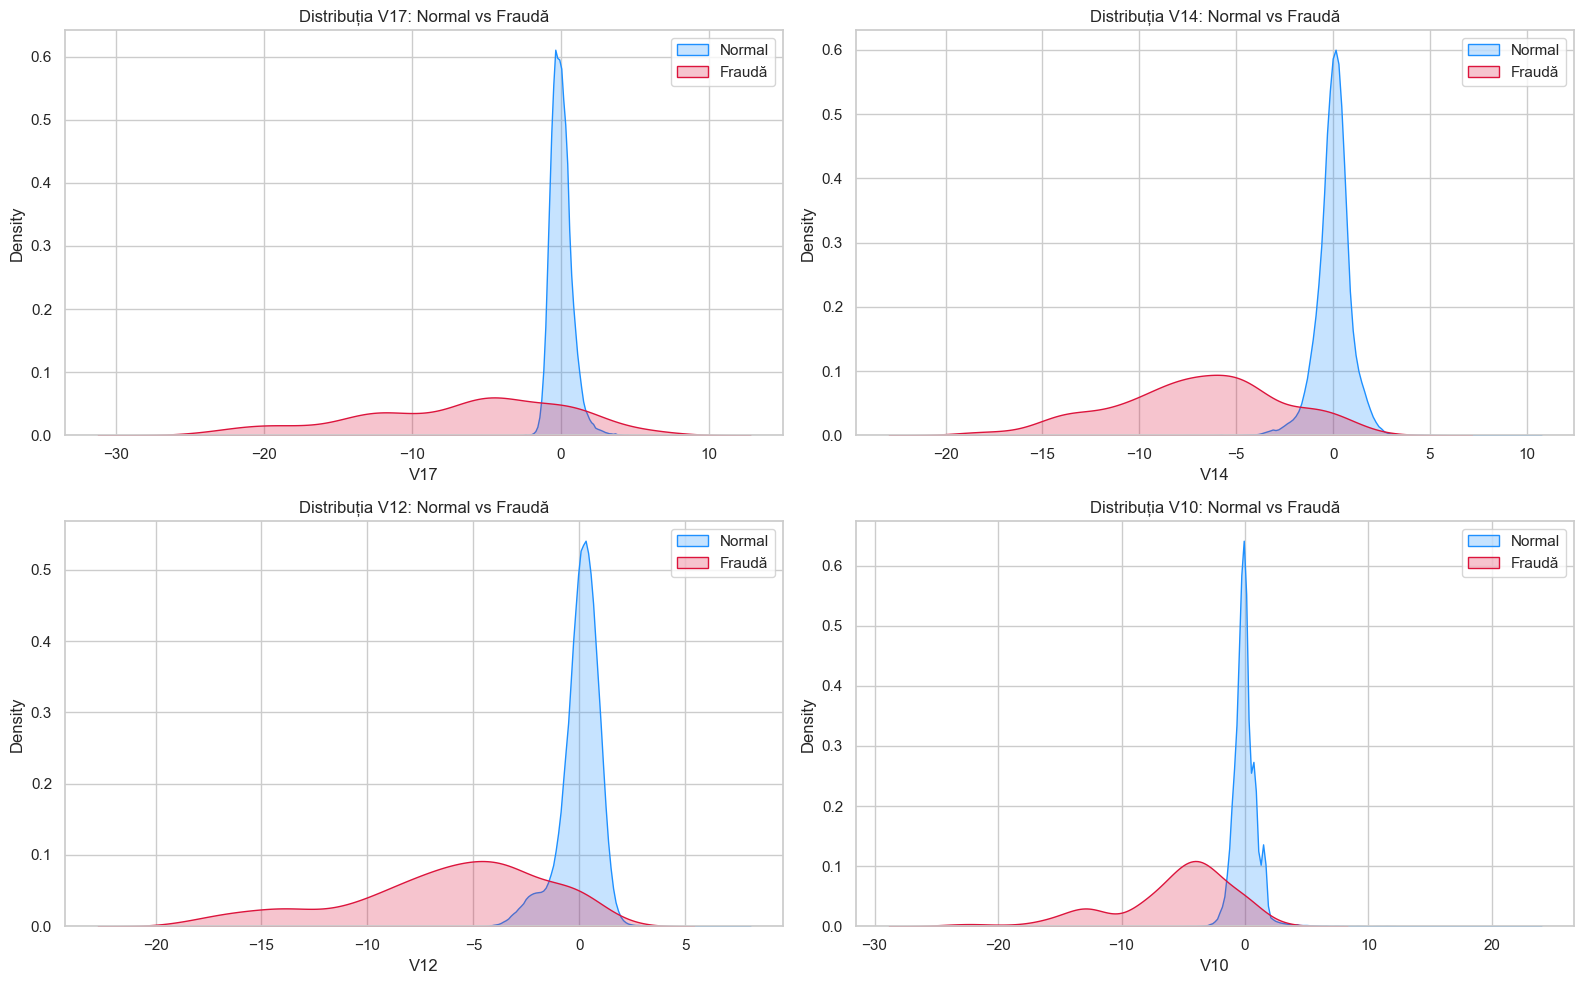

In [9]:
# Alegem variabilele cu cea mai mare corelație negativă
vars_to_plot = ['V17', 'V14', 'V12', 'V10']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    sns.kdeplot(df_real[df_real['Class'] == 0][col], label='Normal', fill=True, ax=axes[i], color='dodgerblue')
    sns.kdeplot(df_real[df_real['Class'] == 1][col], label='Fraudă', fill=True, ax=axes[i], color='crimson')
    axes[i].set_title(f'Distribuția {col}: Normal vs Fraudă')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 8. Visualization of Class Separability in 2D Space (t-SNE)
Since the dataset is massive, we use a balanced subset to visualize—using the t-SNE technique—how fraudulent transactions cluster compared to normal ones.

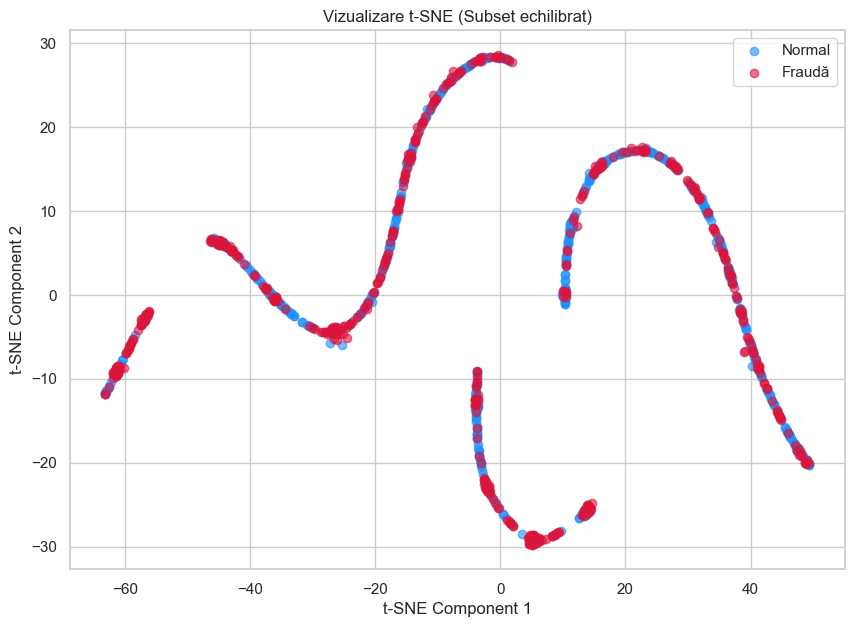

In [11]:
from sklearn.manifold import TSNE

# Creăm un subset echilibrat (toate fraudele + număr egal de tranzacții normale)
frauds = df_real[df_real['Class'] == 1]
non_frauds = df_real[df_real['Class'] == 0].sample(len(frauds), random_state=42)
sub_sample = pd.concat([frauds, non_frauds])

X_vis = sub_sample.drop('Class', axis=1)
y_vis = sub_sample['Class']

# Aplicăm t-SNE pentru a reduce dimensionalitatea la 2D
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_vis)

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[y_vis==0, 0], X_tsne[y_vis==0, 1], label='Normal', alpha=0.6, c='dodgerblue')
plt.scatter(X_tsne[y_vis==1, 0], X_tsne[y_vis==1, 1], label='Fraudă', alpha=0.6, color='crimson')
plt.title('Vizualizare t-SNE (Subset echilibrat)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.show()